### Random Walk with Drift Simulated data
This jupyter notebook contains all the relevant code for the Bachelor AI thesis titled: Forecast-based Anomaly Detection for Students’ Inconsistent Performance on Time Series Trace Data. Due to the data used in the project being protected under a NDA, this entire notebook can be ran on similar student trajectories which are simulated by a Random Walk with Drift (RWwD).

In [1]:
#---Imports---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")
from matplotlib import colormaps

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
from pymc.sampling.jax import sample_blackjax_nuts

import matplotlib.patches as mpatches
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from statsmodels.tsa.stattools import adfuller

/Users/rafsluijters/anaconda3/envs/HHAIR_thesis/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


The following code block contains all functions needed to run the RWwD model.

In [2]:
#---Functions for running RWwD---
def RWwD(train):
    '''
    Runs the Random Walk with Drift sampling, first the data is differenced afterwhich the model is ran and the trace collected
    input:
    -train = simulated array of student Elo ratings
    returns:
    -trace = the sampled parameters
    '''
    coords={
        "time": range(len(train) - 2), 
        "var": ["studentAbility"],
    }
    train_diffs = np.diff(train.flatten())[:, None] 
    with pm.Model(coords=coords) as RWwD_model:
        alpha = pm.Normal("alpha", mu=0.0, sigma=0.1, dims=("var",)) 
        sigma = pm.HalfNormal("sigma", sigma=0.5, dims=("var",))
        obs = pm.Normal("obs", mu=alpha, sigma=sigma, observed=train_diffs[1:], dims=("time", "var"))
        trace = pm.sample(1000, cores=4)
    return trace

def forecast(forecast_length, train, alpha, sigma):
    '''
    Forecasting function. Takes the length the forecast is meant to be and the last rating of the train set. Next the RW's normal
    distribution is combined with this last rating.
    input:
    -forecast_length = length of the forecast
    -train = simulated array of student Elo ratings
    -alpha = sampled alpha posterior
    -sigma = sampled sigma posterior
    returns:
    -forecast = forecasted distribution after the last train data point
    '''
    pred_trajectory = [train.flatten()[-1]] 
    for i in range(forecast_length):
        drift = alpha
        step_shock = np.random.normal(0, sigma)
        next_raw_score = pred_trajectory[-1] + drift + step_shock
        pred_trajectory.append(next_raw_score) 
    forecast = xr.concat(pred_trajectory[1:], dim="time").squeeze().transpose(..., "time")
    return forecast

def run(elo_values, stepsize):
    '''
    The run function takes both the elo_values and the stepsize. The run function loops through the entire trajectory adn makes the
    train data which is in turn used as input for the RWwD function. After running the model we forecast
    input:
    -elo_values = simulated array of student Elo ratings
    -stepsize = size of the steps when we want to run the model and forecast
    returns:
    -forecasts = the forecasts
    -vals = the elo rating values
    -alpha = the final posterior samples for alpha
    -sigma = the final posterior samples for sigma
    '''
    vals = []
    forecasts = []
    for i, val in enumerate(elo_values):
        vals.append(val)
        if (i+1) % stepsize == 0:
            if len(vals) >= 3:
                train_array = np.array(vals)
                trace = RWwD(train_array)
                alpha = trace.posterior["alpha"]
                sigma = trace.posterior["sigma"]
                forecast_length = 3
                train = np.array(vals)
                forecasted_trajectory = forecast(forecast_length, train, alpha, sigma)
                forecasts.append(forecasted_trajectory)
    return forecasts, vals, alpha, sigma

def simulate_RWwD_bounded(steps):
    '''
    Function that simulates the student trajectories on the basis of the projects prior parameters without being informed on
    the data.
    input:
    -steps = steps on how long to forecast
    returns:
    absolute_score = final simulated student trajectory
    '''
    intercept = np.random.normal(0.0, 0.1)
    noise = np.abs(np.random.normal(0, 0.5)) 
    absolute_score = [-1.0]
    jump_trajectory = [0.0] 
    for t in range(steps):
        error = np.random.normal(0, noise)
        next_jump = intercept + error
        raw_score = absolute_score[-1] + next_jump
        clipped_score = np.clip(raw_score, -2.0, 2.0)
        jump_trajectory.append(next_jump)
        absolute_score.append(clipped_score)
    return absolute_score

#The following functions were omitted as we simulate the student trajectories and therefore do not use the actual dataframe
def target_df():
    #filtering the dataframe to get the student at their respective id and their correct date and time
    return 

def elo_values():
    #further cleaning of the single student by cleaning all other categories besides their Elo ratings
    return

In the next code block, we collect the simulated elo rating trajectory. Note that this a more constrained version of the simulated_RWwD_bounded function defined in the previous code snippet. The more constrained version is informed from the dataset (see the priors for the intercept and noise), which allows for accurately indicating how the rest of the thesis code works, feel free to play with the parameters (as noted in the comments).

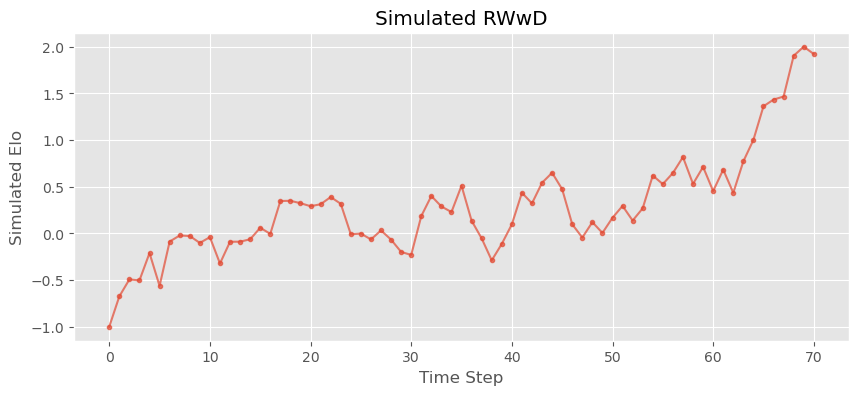

In [3]:
#---Simulating student trajectory---

#run until a sensible trajectory which looks similar to the plotted trajectories in the thesis is simulated
mu = np.random.normal(0.02, 0.03) #change to e.g. mu = np.random.normal(0.0, 0.10)
sigma = np.abs(np.random.normal(0, 0.25)) #change to e.g. sigma = np.abs(np.random.normal(0, 0.5)) 
simulated_trajectory = [-1.0]
jump_trajectory = [0.0] 

for t in range(70):
    noise = np.random.normal(0, sigma)
    next_jump = mu + noise
    raw_score = simulated_trajectory[-1] + next_jump
    clipped_score = np.clip(raw_score, -2.0, 2.0)
    jump_trajectory.append(next_jump)
    simulated_trajectory.append(clipped_score)
plt.figure(figsize=(10, 4))
plt.plot(simulated_trajectory, marker='o', markersize=3, alpha=0.7)
plt.title("Simulated RWwD")
plt.xlabel("Time Step")
plt.ylabel("Simulated Elo")
plt.show()


The following code block contains the code for the model validation. The simulated trajectories are ran with the non constrained priors. The ADF-statistic might denote stationarity depending on what sort of simulated trajectory is ran. In general, most students from the dataset exhibited non-stationary data, therefore the modeling decisions where taken in such a manner, as a small subset of the students was marked as stationary.

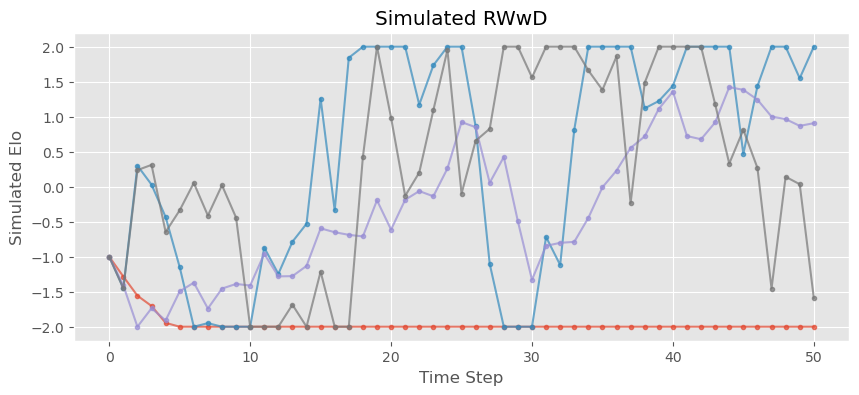

ADF Statistic: -1.0388819707376205
p-value: 0.7388202522214082
Non-Stationarity: fail to reject the null hypothesis


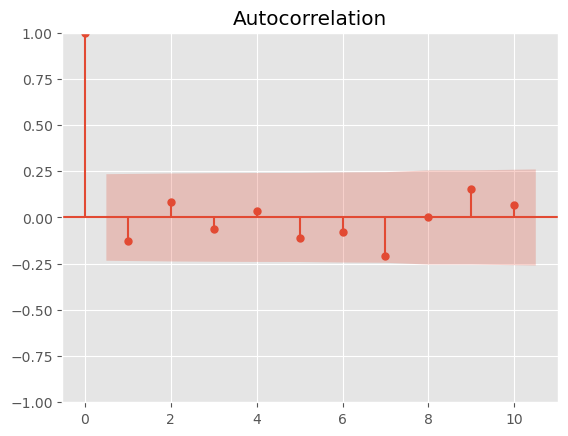

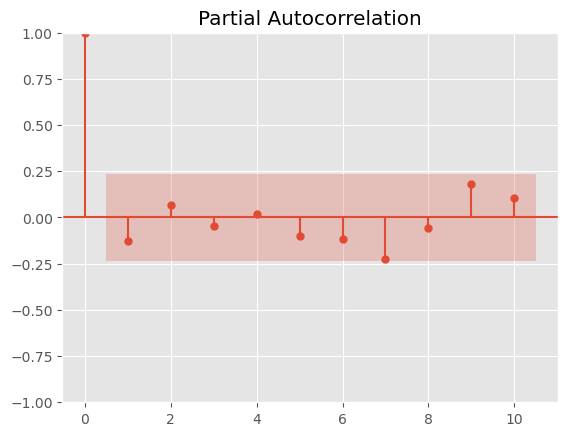

In [4]:
#---Model validation---

steps = 50
plt.figure(figsize=(10, 4))
for _ in range(4):
    plt.plot(simulate_RWwD_bounded(steps), marker='o', markersize=3, alpha=0.7)
plt.title("Simulated RWwD")
plt.xlabel("Time Step")
plt.ylabel("Simulated Elo")
plt.show()

result = adfuller(simulated_trajectory)
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")
if result[1] < 0.05:
    print("Stationarity: reject the null hypothesis")
else:
    print("Non-Stationarity: fail to reject the null hypothesis")

simulated_trajectory_diffs = np.diff(np.array(simulated_trajectory).flatten())


plot_acf(simulated_trajectory_diffs, lags=10) 
plot_pacf(simulated_trajectory_diffs, lags=10) 
plt.show()


Now we make use of the run function from the functions block above, to collect the forecasts.

In [5]:
#---Collecting the forecasts---
stepsize=1
forecasts, vals, alpha, sigma = run(np.array(simulated_trajectory),stepsize)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, sigma]


/Users/rafsluijters/anaconda3/envs/HHAIR_thesis/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
There were 123 divergences after tuning. Increase `target_accept` or reparameterize.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, sigma]


/Users/rafsluijters/anaconda3/envs/HHAIR_thesis/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.
There were 29 divergences after tuning. Increase `target_accept` or reparameterize.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, sigma]


...

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, sigma]


/Users/rafsluijters/anaconda3/envs/HHAIR_thesis/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, sigma]


/Users/rafsluijters/anaconda3/envs/HHAIR_thesis/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


In [6]:
#---Plotting and quantification of difference---
def quantify_difference_actual_forecast(forecasts, vals, fnum):
    '''
    This function quantifies the difference between the forecast and the actual data. It alligns the forecasts and elo values and
    afterwards computes the d-values which is a measurement of the tail probability
    input:
    -forecasts = the forecasted distributions
    -vals = student elo rating values
    -fnum = the length of the forecast
    returns:
    -d_values = the quantile probabilites
    '''
    all_forecast_draws = []
    etis_bounds_list = []
    observed_target_vals = []

    for forecast in forecasts:
        samples_step = forecast.isel(time=(fnum-1)).values.flatten()
        all_forecast_draws.append(samples_step)
        lower_bound = np.quantile(samples_step, 0.025)
        upper_bound = np.quantile(samples_step, 0.975)
        etis_bounds_list.append((lower_bound, upper_bound))
    for i, v in enumerate(vals): 
        if i > 4:            
            observed_target_vals.append(v)
    min_len = min(len(vals), len(all_forecast_draws))
    
    aligned_forecasts = all_forecast_draws[:min_len]
    aligned_etis = etis_bounds_list[:min_len]
    aligned_obs = observed_target_vals
    d_values = []
    for i, (forecast, observed, eti) in enumerate(zip(aligned_forecasts, aligned_obs, aligned_etis)):
        count = np.sum(forecast < observed)
        percentile = count / len(forecast)
        tail_prob = min(percentile, 1 - percentile) 
        d_values.append(tail_prob)
        if observed < eti[0] or observed > eti[1]: 
            print(f"Forecast #{i+1} possible inconsistency; {tail_prob}")
    return d_values

def plot_forecasts_dvalues(elo_values, forecasts, stepsize, d_values):
    '''
    Plotting function for the student trace, the forecasts and d quantile probability. 
    input:
    -elo_values = student trace data
    -forecasts = the forecasted distributions
    -stepsize = size of the steps the model was ran on
    -d_values = the quantile probabilites
    output:
    -the plot
    '''
    observed = range(len(elo_values))
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

    ax1.plot(observed, elo_values, "o-", markersize=4, alpha=0.5, label='Observed Student Data')
    warmup_period = 3
    first_trigger_idx = stepsize * ((warmup_period + stepsize - 1) // stepsize)

    for i, forecast in enumerate(forecasts):
        start_idx = first_trigger_idx + (i * stepsize)
        forecast_mean = forecast.mean(["chain", "draw"])
        forecast_len = len(forecast_mean)
        forecast_indices = range(start_idx, start_idx + forecast_len)
        lower_bound = forecast.quantile(0.025, dim=["chain", "draw"])
        upper_bound = forecast.quantile(0.975, dim=["chain", "draw"])

        anchor_idx = start_idx - 1
        if anchor_idx < len(elo_values):
            anchor_val = elo_values[anchor_idx]
        else:
            anchor_val = forecast_mean[0].values

        forecast_indices = range(anchor_idx, start_idx + forecast_len)
        extended_lower = np.insert(lower_bound, 0, anchor_val)
        extended_upper = np.insert(upper_bound, 0, anchor_val)
        ax1.fill_between(forecast_indices, extended_lower, extended_upper, color='limegreen', alpha=0.12)
        ax1.fill_between(forecast_indices[1:], extended_lower[1:], extended_upper[1:], color='limegreen', alpha=0.14)
        ax1.fill_between(forecast_indices[2:], extended_lower[2:], extended_upper[2:], color='limegreen', alpha=0.16)
        ax1.plot(forecast_indices[3], forecast_mean[2], "o", color='limegreen', markersize=3.5, alpha=0.45)

    ax1.set_ylabel('Rating')
    ax1.set_title('Random Walk with Drift; 3-Step Forecasts & Quantile probability d')
    eti_patch = mpatches.Patch(color='limegreen', alpha=0.35, label='95% ETI')

    handles, labels = ax1.get_legend_handles_labels()
    handles.append(eti_patch)
    labels.append(eti_patch.get_label())

    ax1.legend(handles=handles, labels=labels, loc='upper right')

    warmup_period = 3
    first_pvalue_idx = warmup_period + 2
    pvalue_target_indices = range(first_pvalue_idx, first_pvalue_idx + len(d_values))

    ax2.plot(pvalue_target_indices, d_values, "o-", color='darkmagenta', markersize=5, label='Quantile probability d')
    ax2.axhline(0.03, color='red', linestyle='--', lw=2, label='d-value threshold = 0.05')

    
    ax2.set_ylabel('d-value')
    ax2.set_xlabel('Time step')
    ax2.set_ylim(-0.05, 0.55) 
    ax2.legend(loc='upper right')
    plt.subplots_adjust(hspace=0.05) 
    plt.show()
    return

Forecast #34 possible inconsistency; 0.01
Forecast #43 possible inconsistency; 0.02075
Forecast #61 possible inconsistency; 0.008499999999999952


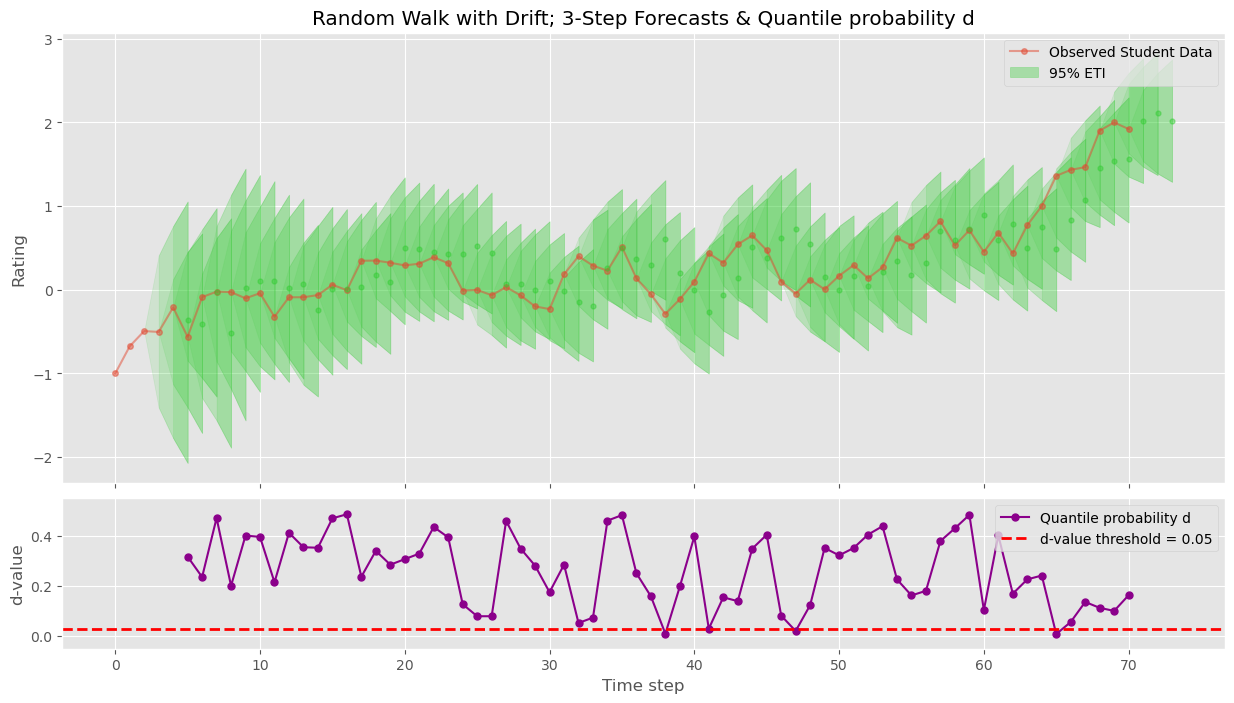

In [8]:
fnum = 3
d_values = quantify_difference_actual_forecast(forecasts,vals,fnum)
plot_forecasts_dvalues(vals, forecasts, stepsize,d_values)